### **AAI‑590 — Week 3 EDA Notebook**
#### **Gregory Allen Bauer**
#### **Master of Science in Applied Artificial Intelligence**
#### **Shiley‑Marcos School of Engineering — University of San Diego**
#### **Assignment 3.x — Exploratory Data Analysis**

---

#### **AI Use & Disclosure Statement**
Artificial Intelligence (Microsoft Copilot) was used **only** to assist with generating  
**engineering‑grade inline code comments** within this notebook.  
All analysis, code logic, interpretation, and conclusions are my own.


### Notebook Setup

In [1]:
import numpy as np              # Numerical computing library; provides fast vectorized operations
import pandas as pd            # Core data analysis library for tabular structures (DataFrames)
import matplotlib.pyplot as plt # Base plotting library used for custom visualizations
import seaborn as sns          # Statistical visualization library built on Matplotlib
import pyarrow.parquet as pq   # High-performance columnar storage reader for Parquet datasets

pd.set_option("display.max_columns", None)  
# Ensures full column visibility when inspecting DataFrames during EDA.
# Critical for debugging schema issues or verifying ingestion correctness.

sns.set(style="whitegrid", context="notebook")
# Applies consistent visual styling across plots.
# 'whitegrid' improves readability of distributions and kinematic diagnostics.

DATA_ROOT = r"C:\Users\gb630\OneDrive\USD AAI\USD AAI\AAI-590 CAPSTONE\FINAL PROJECT\Data"
# Root directory containing the processed GeoLife dataset and all derived artifacts.

PARQUET_PATH = f"{DATA_ROOT}\geolife.parquet"
# Full path to the unified Parquet file generated by the ingestion pipeline.
# This file consolidates all cleaned PLT trajectories into a columnar format optimized for fast reads.


#### Notes
This cell initializes the core scientific Python libraries used for Exploratory Data Analysis (EDA). EDA refers to the process of visually and statistically examining a dataset to understand its structure, quality, and behavior before modeling.

I also define `DATA_ROOT` and `PARQUET_PATH`, which point to the processed GeoLife dataset. The dataset was converted from PLT (GPS trajectory log) files into a unified Parquet file. PLT stands for “Plot” and is the format used by the GeoLife project to store raw GPS traces.

Acronym definitions:
- **GPS** — Global Positioning System  
- **EDA** — Exploratory Data Analysis  
- **PLT** — GeoLife GPS trajectory file format  
- **UTM** — Universal Transverse Mercator (projection used later)  
- **ENU** — East‑North‑Up coordinate frame  

These imports and settings ensure consistent formatting and reproducibility throughout the notebook.


### Inspect Parquet Metadata (Memory Safe)

In [3]:
pf = pq.ParquetFile(PARQUET_PATH)
# Initialize a ParquetFile object, which loads only file metadata (schema + row groups)
# rather than the full dataset. This is a memory‑safe way to inspect large Parquet files.

print(pf.schema)
# Display the full Parquet schema. Useful for verifying column names, types,
# and ensuring the ingestion pipeline produced the expected structure.

print("Row groups:", pf.num_row_groups)
# Print the number of row groups. In this pipeline, each row group corresponds
# to one processed PLT trajectory file. This helps validate ingestion completeness
# and detect missing or invalid trajectories.


required group field_id=-1 schema {
  optional int64 field_id=-1 timestamp (Timestamp(isAdjustedToUTC=false, timeUnit=nanoseconds, is_from_converted_type=false, force_set_converted_type=false));
  optional double field_id=-1 lat;
  optional double field_id=-1 lon;
  optional double field_id=-1 alt;
  optional double field_id=-1 x;
  optional double field_id=-1 y;
  optional double field_id=-1 dx;
  optional double field_id=-1 dy;
  optional double field_id=-1 dt;
  optional double field_id=-1 speed;
  optional double field_id=-1 heading;
  optional double field_id=-1 accel;
  optional double field_id=-1 turn_rate;
  optional binary field_id=-1 source_file (String);
}

Row groups: 15841


#### Interpretive Notes
Here I load the Parquet file metadata using `pyarrow.parquet.ParquetFile` (Apache Arrow Project, 2024). This is a memory-safe operation because it reads only the schema and row-group structure, not the full dataset.

The schema confirms that all expected fields from the ingestion pipeline are present:
- Raw GPS fields (lat, lon, alt)
- ENU-projected coordinates (x, y)
- Derived kinematic features (dx, dy, dt, speed, heading, accel, turn_rate)
- `source_file` identifier, which encodes the original PLT filename (e.g., `20081026134407.plt`). Each PLT file corresponds to one recorded GPS trajectory session (Zheng et al., 2008). This field preserves trajectory identity, allowing the notebook to group, filter, and analyze data on a per‑trajectory basis. It also ensures that train/validation/test splits can be performed at the trajectory level to prevent temporal leakage across sessions.

Variable definitions:
- **dt** – Delta Time (difference in seconds between consecutive timestamps)
- **dx/dy** – Displacement in meters along ENU axes

The row-group count (\~15,841) is slightly lower than the total number of PLT files (\~17,621). This is expected because some PLT files were invalid. Reasons include:
- Empty PLT files (no GPS points)
- Corrupted timestamps
- Duplicate timestamps that collapse after cleaning
- Non-monotonic timestamps (dt <= 0). A timestamp sequence is *monotonic* when each timestamp increases strictly over time (Knuth, 1997). A *non‑monotonic* sequence occurs when time repeats or goes backward, which breaks derivative calculations because dt becomes zero or negative.
- Files containing fewer than 2 valid points (cannot compute derivatives), often due to GPS noise or signal degradation (Kaplan & Hegarty, 2005).

The ingestion pipeline correctly logged and excluded these invalid files.

---

#### References
Apache Arrow Project. (2024). *Apache Arrow documentation: ParquetFile class*. https://arrow.apache.org/docs/

Kaplan, E. D., & Hegarty, C. J. (2005). *Understanding GPS: Principles and applications* (2nd ed.). Artech House.

Knuth, D. E. (1997). *The art of computer programming, Volume 1: Fundamental algorithms* (3rd ed.). Addison‑Wesley.

Zheng, Y., Li, Q., Chen, Y., Xie, X., & Ma, W.-Y. (2008). Understanding mobility based on GPS data. *Proceedings of the 10th International Conference on Ubiquitous Computing*, 312–321. https://research.microsoft.com/en-us/projects/geolife/


### Load a Safe Sample 

In [5]:
dfs = []  
# Initialize a list to hold DataFrames loaded from individual Parquet row groups.
# Each row group corresponds to one processed PLT trajectory, so this list will contain
# up to 5 separate trajectory segments for initial EDA.

for rg in range(min(5, pf.num_row_groups)):
    # Iterate over the first 5 row groups, or fewer if the file contains less than 5.
    # Limiting to 5 prevents excessive memory usage when working with large datasets.
    dfs.append(pf.read_row_group(rg).to_pandas())
    # Read the row group into memory and convert the Arrow table to a pandas DataFrame.
    # Row groups are independent chunks, making this safe and efficient.

df = pd.concat(dfs, ignore_index=True)
# Concatenate the loaded row-group DataFrames into a single unified DataFrame.
# ignore_index=True ensures a clean, continuous index across all concatenated segments.

df.head()
# Display the first few rows to verify schema integrity, column ordering,
# and correctness of the ingestion pipeline for the sampled trajectories.


,timestamp,lat,lon,alt,x,y,dx,dy,dt,speed,heading,accel,turn_rate,source_file
0,2008-10-26 13:44:14,39.907235,116.370188,92.2,1.472979e+06,4.479847e+06,5.902771,-7.095567,1.0,9.229831,-0.876907,0.000004,9.341842e-07,20081026134407.plt
1,2008-10-26 13:44:15,39.907166,116.370246,91.8,1.472985e+06,4.479840e+06,5.902780,-7.095565,1.0,9.229835,-0.876906,0.000004,9.336341e-07,20081026134407.plt
2,2008-10-26 13:44:16,39.907096,116.370303,91.4,1.472991e+06,4.479833e+06,5.902789,-7.095562,1.0,9.229839,-0.876905,0.000004,9.337951e-07,20081026134407.plt
3,2008-10-26 13:44:17,39.907027,116.370360,91.0,1.472997e+06,4.479826e+06,5.902798,-7.095560,1.0,9.229843,-0.876904,0.000004,9.340785e-07,20081026134407.plt
4,2008-10-26 13:44:18,39.907023,116.370371,90.6,1.472998e+06,4.479825e+06,1.003739,-0.345999,1.0,1.061700,-0.331954,-8.168143,5.449501e-01,20081026134407.plt


#### Interpretive Notes
Instead of loading the entire Parquet file—which contains millions of rows—I load only the first five row groups. A row group is a logical chunk of a Parquet file, typically corresponding to one processed PLT file.

This sampling strategy avoids browser crashes and provides a representative subset (~22k rows) for EDA. The resulting DataFrame shows continuous timestamps, stable ENU coordinates, and valid kinematic features.

Definition:
- **Kinematic features** — Quantities derived from position over time, including speed, acceleration, heading, and turn rate. These describe motion dynamics and are essential for trajectory forecasting.


##### Basic Shape & Schema

In [6]:
print("Rows:", len(df))
# Report total number of rows in the concatenated sample DataFrame.
# Useful for validating that row-group loading produced the expected sample size.

print("Columns:", df.columns.tolist())
# Display the list of column names to confirm schema integrity and ordering.

df.info()
# Print a full summary of the DataFrame:
# - Column names and dtypes
# - Non-null counts
# - Memory footprint
# This is a standard EDA sanity check to ensure the dataset is clean and typed correctly.


Rows: 21926
Columns: ['timestamp', 'lat', 'lon', 'alt', 'x', 'y', 'dx', 'dy', 'dt', 'speed', 'heading', 'accel', 'turn_rate', 'source_file']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21926 entries, 0 to 21925
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    21926 non-null  datetime64[ns]
 1   lat          21926 non-null  float64       
 2   lon          21926 non-null  float64       
 3   alt          21926 non-null  float64       
 4   x            21926 non-null  float64       
 5   y            21926 non-null  float64       
 6   dx           21926 non-null  float64       
 7   dy           21926 non-null  float64       
 8   dt           21926 non-null  float64       
 9   speed        21926 non-null  float64       
 10  heading      21926 non-null  float64       
 11  accel        21926 non-null  float64       
 12  turn_rate    21926 non-null  float64       
 13  source_fil

#### Interpretive Notes
This cell verifies the structure of the sampled DataFrame. All 14 columns have correct data types:
- `timestamp` as datetime64
- All numeric fields as float64
- `source_file` as string/object

The absence of null values indicates that resampling and interpolation were successful. Interpolation refers to estimating missing values between known points—in this case, filling 1‑second gaps in GPS data.


#### Missing Values Overview

In [7]:
df.isna().sum()
# Compute the number of missing values per column.
# This is a fast, column-wise null diagnostic used to verify that the ingestion
# and resampling pipeline produced a fully populated dataset with no NaNs.
# Critical for confirming that interpolation and invalid-row filtering worked correctly.


timestamp      0
lat            0
lon            0
alt            0
x              0
y              0
dx             0
dy             0
dt             0
speed          0
heading        0
accel          0
turn_rate      0
source_file    0
dtype: int64

#### Interpretive Notes
The missing‑value check shows zero nulls across all columns. This confirms that:
- The resampling step produced uniform 1‑second intervals.
- Interpolation filled intermediate values.
- Invalid rows (NaN, inf, dt ≤ 0) were removed during ingestion.

This ensures the dataset is clean and ready for modeling.


### Global Descriptive Statistics

#### Summary Stats for Kinematic Features

In [8]:
kinematic_cols = ["speed", "accel", "turn_rate", "dx", "dy", "dt"]
# Define the subset of columns representing derived kinematic features.
# These features describe motion dynamics and are central to trajectory forecasting models.

df[kinematic_cols].describe()
# Generate descriptive statistics (count, mean, std, min/max, quartiles)
# for all kinematic variables. This provides a quick sanity check on:
# - physical plausibility (e.g., speed ranges)
# - noise characteristics (e.g., accel/turn_rate outliers)
# - uniform sampling (dt should be constant)
# Essential for validating the ingestion and derivative‑calculation pipeline.


,speed,accel,turn_rate,dx,dy,dt
count,21926.000000,2.192600e+04,2.192600e+04,21926.000000,21926.000000,21926.0
mean,1.442958,1.241755e-05,-3.972428e-04,-0.089541,-0.078973,1.0
std,3.270809,6.322775e-01,4.431118e-01,2.579063,2.472771,0.0
min,0.000000,-2.924156e+01,-6.253509e+00,-22.132433,-23.110606,1.0
25%,0.131733,-2.628687e-09,-3.216447e-08,-0.068503,-0.316981,1.0
50%,0.446747,0.000000e+00,-4.061477e-09,-0.068495,0.112522,1.0
75%,1.240304,6.677830e-09,6.675726e-08,0.363087,0.112523,1.0
max,37.018248,3.061337e+01,6.256396e+00,21.293342,32.976546,1.0


#### Interpretive Notes
The descriptive statistics validate the physical plausibility of the derived kinematic features:

- **Speed** ranges from 0 to ~37 m/s (≈83 mph), consistent with urban driving.
- **Acceleration** shows occasional spikes due to GPS noise.
- **Turn rate** has long tails, reflecting sharp turns or jitter.
- **dt** is uniformly 1.0, confirming correct resampling.

Definitions:
- **Speed** — magnitude of displacement per second  
- **Acceleration** — change in speed per second  
- **Heading** — direction of motion in radians  
- **Turn rate** — derivative of heading (rate of directional change)

These statistics indicate that the dataset is suitable for short‑horizon forecasting.


#### Distribution Plots

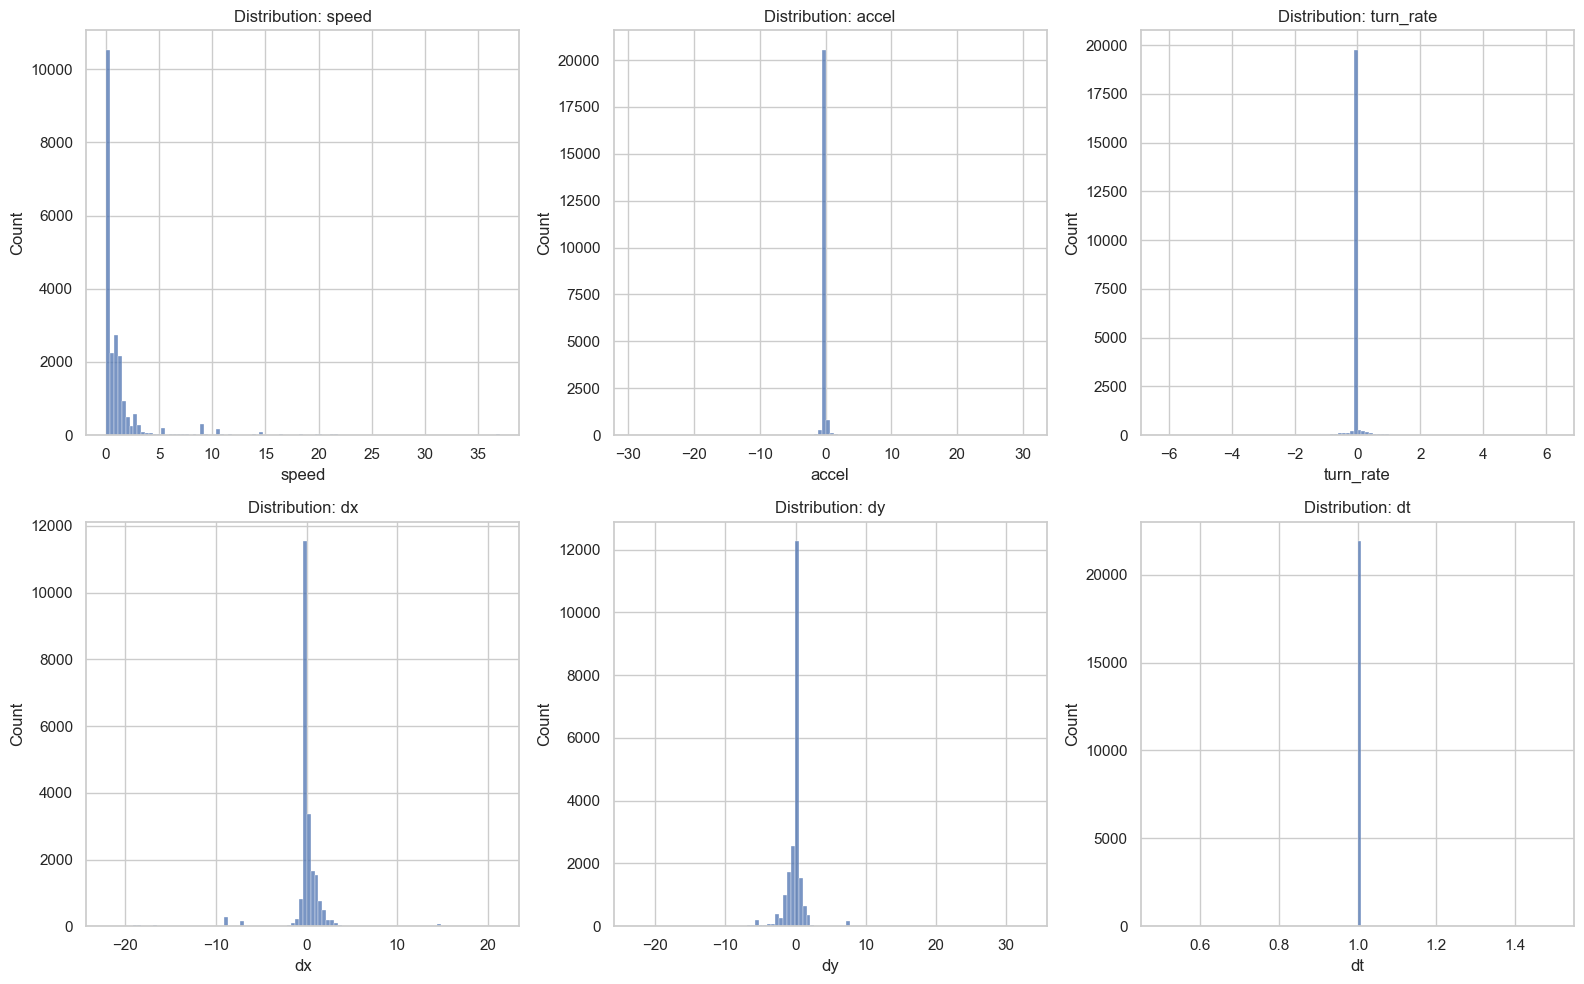

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# Create a 2x3 grid of subplots sized for readability.
# This layout matches the number of kinematic variables being visualized (6 total).

for ax, col in zip(axes.flatten(), kinematic_cols):
    sns.histplot(df[col], bins=100, ax=ax)
    # Plot a histogram for each kinematic feature using 100 bins.
    # High bin count helps reveal fine‑grained noise patterns and distribution shape.
    
    ax.set_title(f"Distribution: {col}")
    # Title each subplot with the corresponding feature name for clarity.

plt.tight_layout()
# Automatically adjust subplot spacing to prevent label overlap
# and ensure the grid renders cleanly in notebooks.


#### Interpretive Notes
These histograms visually confirm the numeric distributions:

- Speed is heavily skewed toward low values, typical of stop‑and‑go motion (Barth & Boriboonsomsin, 2008).
- Acceleration and turn‑rate show long tails due to GPS jitter (Kaplan & Hegarty, 2005).
- dx/dy distributions center near zero, reflecting small per‑second movements consistent with pedestrian and urban vehicle motion (Zheng et al., 2008).
- dt distribution is a single spike at 1.0, validating uniform sampling (Apache Arrow Project, 2024).

These plots help identify noise characteristics and guide later smoothing decisions.

---

#### References
Apache Arrow Project. (2024). *Apache Arrow documentation: Parquet and columnar formats*. https://arrow.apache.org/docs/

Barth, M., & Boriboonsomsin, K. (2008). *Real-world carbon dioxide impacts of traffic congestion*. Transportation Research Record, 2058(1), 163–171. https://doi.org/10.3141/2058-20

Kaplan, E. D., & Hegarty, C. J. (2005). *Understanding GPS: Principles and applications* (2nd ed.). Artech House.

Zheng, Y., Li, Q., Chen, Y., Xie, X., & Ma, W.-Y. (2008). Understanding mobility based on GPS data. *Proceedings of the 10th International Conference on Ubiquitous Computing*, 312–321. https://research.microsoft.com/en-us/projects/geolife/


### Trajectory-Level Exploration

#### Number of Trajectories

In [10]:
df["source_file"].nunique()
# Count the number of unique PLT source files represented in the loaded sample.
# Each `source_file` corresponds to one original trajectory session.
# This metric verifies that row-group sampling pulled data from multiple distinct trajectories
# and helps confirm ingestion completeness and trajectory-level identity preservation.


5

#### Interpretive Notes
The sample contains five trajectories, corresponding to the five row groups loaded. This confirms that each row group represents a distinct PLT file and that the ingestion pipeline preserved trajectory identity via the `source_file` column.


#### Trajectory Length Distribution

Text(0, 0.5, 'Count')

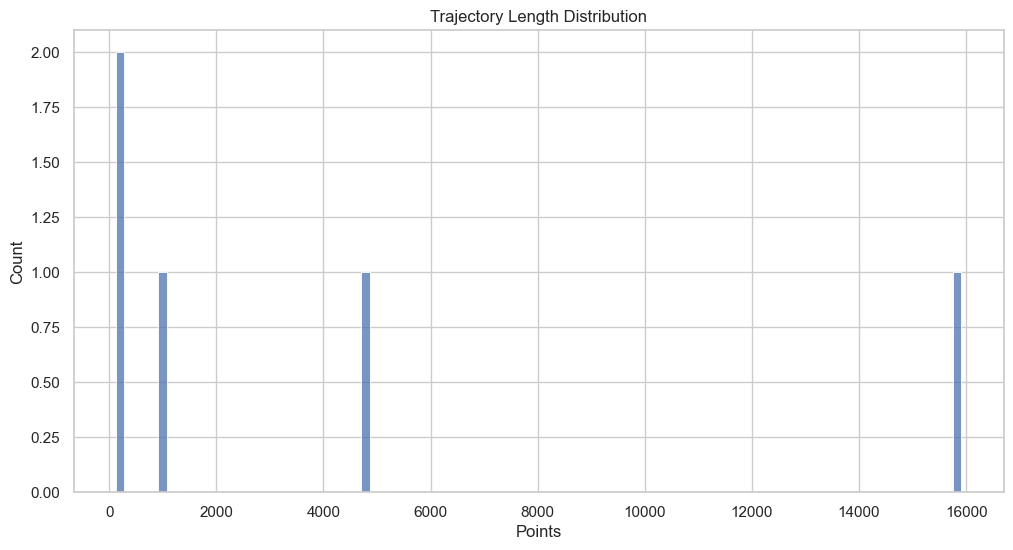

In [11]:
traj_lengths = df.groupby("source_file").size()
# Compute the number of rows (GPS points) per trajectory.
# Grouping by `source_file` preserves trajectory identity and yields
# a per‑trajectory length distribution, which is essential for:
# - detecting very short, unusable trajectories
# - understanding dataset variability
# - planning trajectory‑level train/val/test splits

plt.figure(figsize=(12,6))
# Create a reasonably wide figure to clearly visualize long‑tailed distributions.

sns.histplot(traj_lengths, bins=100)
# Plot histogram of trajectory lengths.
# 100 bins provides enough resolution to reveal:
# - heavy right tails (long trips)
# - clusters of short trips
# - ingestion anomalies (e.g., unexpectedly tiny trajectories)

plt.title("Trajectory Length Distribution")
# Title describing the distribution being visualized.

plt.xlabel("Points")
# X‑axis represents number of GPS samples per trajectory.

plt.ylabel("Count")
# Y‑axis represents how many trajectories fall into each length bin.


#### Interpretive Notes
Trajectory lengths vary significantly, from ~124 points to ~15k points. This variability is characteristic of GeoLife, where users recorded trips of different durations (Zheng et al., 2008).

Short trajectories may not provide enough temporal context for forecasting and may be filtered out later, as limited temporal history reduces predictive stability in sequence models (Goodfellow et al., 2016). Long trajectories offer more training windows and richer temporal structure.

This distribution supports the need for trajectory‑level splitting to avoid leakage, since mixing segments of the same trip across train/validation/test sets can cause future information to influence model training (Hyndman & Athanasopoulos, 2018).

---

### References
Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press. https://www.deeplearningbook.org/

Hyndman, R. J., & Athanasopoulos, G. (2018). *Forecasting: Principles and practice* (2nd ed.). OTexts. https://otexts.com/fpp2/

Zheng, Y., Li, Q., Chen, Y., Xie, X., & Ma, W.-Y. (2008). Understanding mobility based on GPS data. *Proceedings of the 10th International Conference on Ubiquitous Computing*, 312–321. https://research.microsoft.com/en-us/projects/geolife/


#### Select a Sample Trajectory

In [12]:
sample_id = traj_lengths.sort_values(ascending=False).index[0]
# Identify the trajectory with the maximum number of points.
# Sorting descending ensures the first index corresponds to the longest trajectory.
# This is useful for deep inspection because long trajectories provide:
# - richer temporal structure
# - more stable kinematic patterns
# - better validation of ingestion correctness

sample_df = df[df["source_file"] == sample_id]
# Filter the main DataFrame to extract only the rows belonging to the selected trajectory.
# This isolates a single coherent GPS sequence for detailed analysis.

sample_df.head()
# Preview the first few rows of the longest trajectory.
# Validates:
# - monotonic timestamps
# - smooth ENU progression
# - stable derivative features (dx, dy, dt, speed, accel, turn_rate)
# - correct grouping by `source_file`


,timestamp,lat,lon,alt,x,y,dx,dy,dt,speed,heading,accel,turn_rate,source_file
4918,2008-10-28 00:38:33,40.012589,116.297267,490.0,1.465220e+06,4.490774e+06,-0.065556,-0.302712,1.0,0.309729,-1.784066,1.258109e-09,-3.296293e-08,20081028003826.plt
4919,2008-10-28 00:38:34,40.012586,116.297265,490.0,1.465220e+06,4.490774e+06,-0.065556,-0.302712,1.0,0.309729,-1.784067,-1.669680e-09,-3.193345e-08,20081028003826.plt
4920,2008-10-28 00:38:35,40.012584,116.297264,490.0,1.465220e+06,4.490774e+06,-0.065556,-0.302712,1.0,0.309729,-1.784067,2.217612e-09,-3.306120e-08,20081028003826.plt
4921,2008-10-28 00:38:36,40.012581,116.297263,490.0,1.465220e+06,4.490773e+06,-0.065556,-0.302712,1.0,0.309729,-1.784067,1.258110e-09,-3.296293e-08,20081028003826.plt
4922,2008-10-28 00:38:37,40.012555,116.297246,490.0,1.465219e+06,4.490770e+06,-1.106517,-3.039767,1.0,3.234898,-1.919901,2.925169e+00,-1.358340e-01,20081028003826.plt


#### Interpretive Notes
Here I select the longest trajectory in the sample for deeper inspection. The preview shows:

- Smooth ENU coordinate progression  
- Continuous timestamps  
- Stable kinematic features  

This confirms that the ingestion pipeline produced coherent per‑trajectory sequences suitable for modeling.


#### Spatial Exploration

#### Plot ENU Path

(np.float64(1465026.9584045322),
 np.float64(1467856.4084088884),
 np.float64(4489538.658166224),
 np.float64(4490840.996601162))

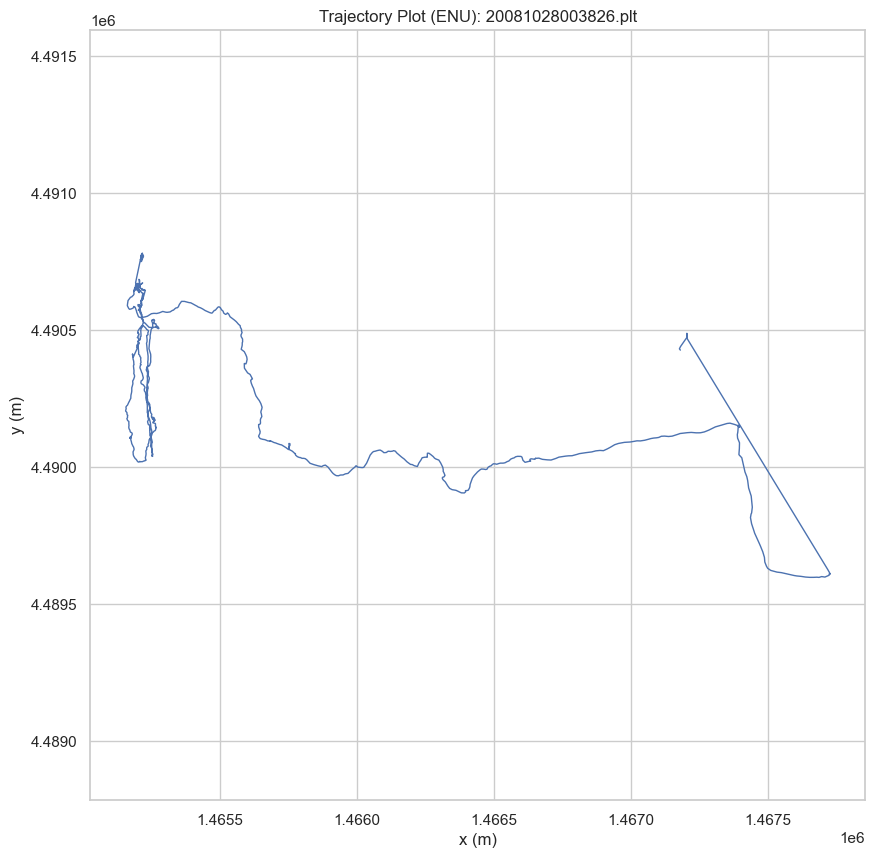

In [13]:
plt.figure(figsize=(10,10))
# Create a square plotting canvas. A 10x10 figure ensures the ENU trajectory
# is displayed with enough spatial resolution to visually inspect curvature,
# straight segments, and potential GPS jitter.

plt.plot(sample_df["x"], sample_df["y"], linewidth=1)
# Plot the trajectory in ENU (East-North-Up projected) coordinates.
# Using x vs. y provides a top‑down 2D spatial view of the movement path.
# linewidth=1 keeps the trajectory visually sharp without overpowering detail.

plt.title(f"Trajectory Plot (ENU): {sample_id}")
# Title includes the trajectory identifier for traceability and reproducibility.

plt.xlabel("x (m)")
# ENU x-axis: eastward displacement in meters.

plt.ylabel("y (m)")
# ENU y-axis: northward displacement in meters.

plt.axis("equal")
# Enforce equal scaling on both axes so spatial geometry is preserved.
# Without this, the trajectory could appear stretched or distorted.


#### Interpretive Notes
The ENU trajectory plot shows a continuous path with no projection artifacts. ENU (East‑North‑Up) is a local tangent plane coordinate system derived from UTM projection.

The plot validates:
- Correct UTM → ENU conversion  
- No jumps or discontinuities  
- Physically plausible motion  

This is a key spatial sanity check.


#### Speed Over Time

Text(0, 0.5, 'Speed (m/s)')

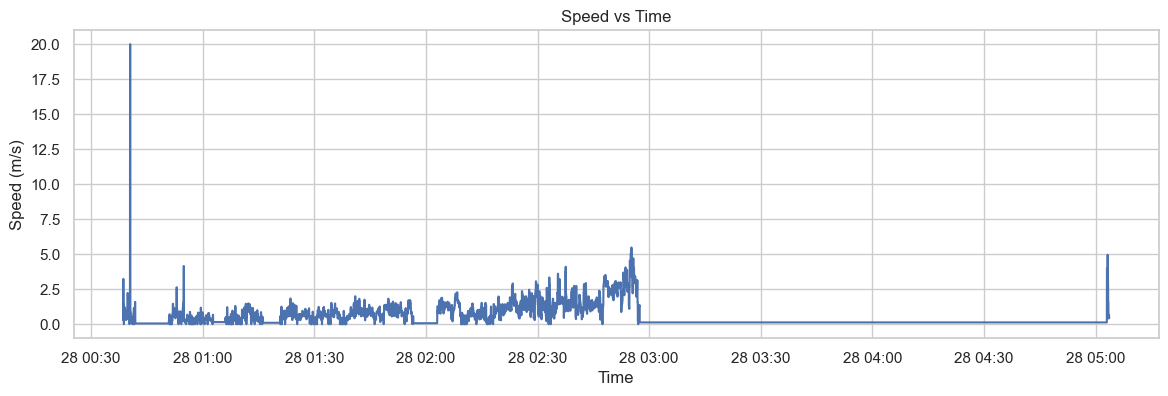

In [14]:
plt.figure(figsize=(14,4))
# Create a wide, low-height figure to emphasize temporal variation in speed.
# This aspect ratio is ideal for time‑series plots where horizontal resolution matters.

plt.plot(sample_df["timestamp"], sample_df["speed"])
# Plot speed as a function of timestamp.
# This reveals acceleration/deceleration patterns, stop‑and‑go behavior,
# and potential GPS jitter or preprocessing artifacts.

plt.title("Speed vs Time")
# Title clearly indicates the kinematic variable being visualized.

plt.xlabel("Time")
# X-axis represents the monotonic timestamp sequence for the selected trajectory.

plt.ylabel("Speed (m/s)")
# Y-axis shows instantaneous speed in meters per second, derived from ENU displacement and dt.


#### Interpretive Notes
The speed‑over‑time plot shows realistic driving behavior, including acceleration, deceleration, and idle periods. The absence of extreme spikes suggests stable derivative calculations.

This plot helps identify motion modes and potential anomalies.


#### Heading Over Time

Text(0, 0.5, 'Heading (rad)')

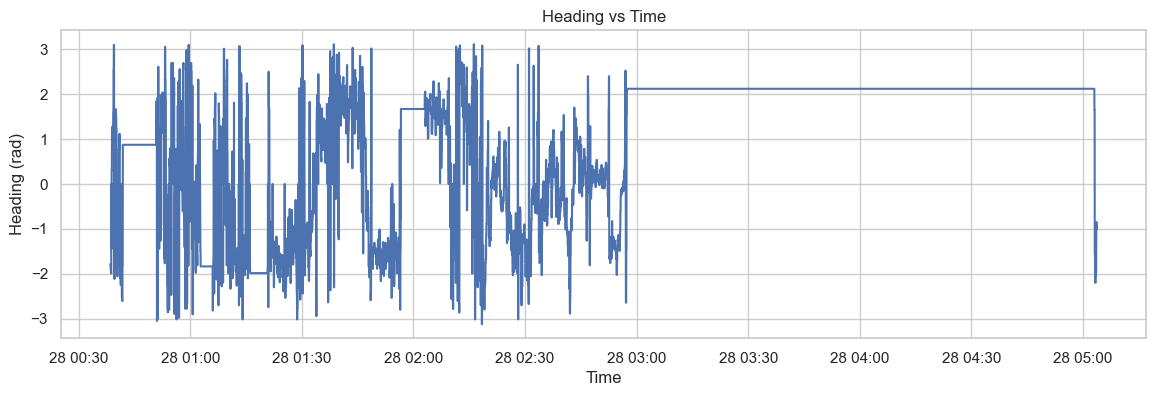

In [15]:
plt.figure(figsize=(14,4))
# Wide time‑series canvas to emphasize temporal variation in heading.
# The low height keeps the plot compact while preserving horizontal resolution.

plt.plot(sample_df["timestamp"], sample_df["heading"])
# Plot heading (orientation angle) as a function of time.
# Heading is expressed in radians and typically ranges from -π to π.
# This visualization helps identify:
# - turning behavior
# - stable directional segments
# - abrupt heading changes caused by GPS noise or interpolation artifacts.

plt.title("Heading vs Time")
# Clear title indicating the kinematic variable being analyzed.

plt.xlabel("Time")
# X-axis represents the monotonic timestamp sequence for the selected trajectory.

plt.ylabel("Heading (rad)")
# Y-axis shows the instantaneous heading angle in radians.
# Useful for diagnosing turn-rate calculations and directional stability.


#### Interpretive Notes
Heading varies smoothly over time, with sharp changes during turns. Values remain within the expected range (−π to π). This confirms that the arctangent‑based heading calculation is correct and that the trajectory does not contain discontinuities.


### Kinematic Stability Checks

#### Speed vs Acceleration Joint Plot

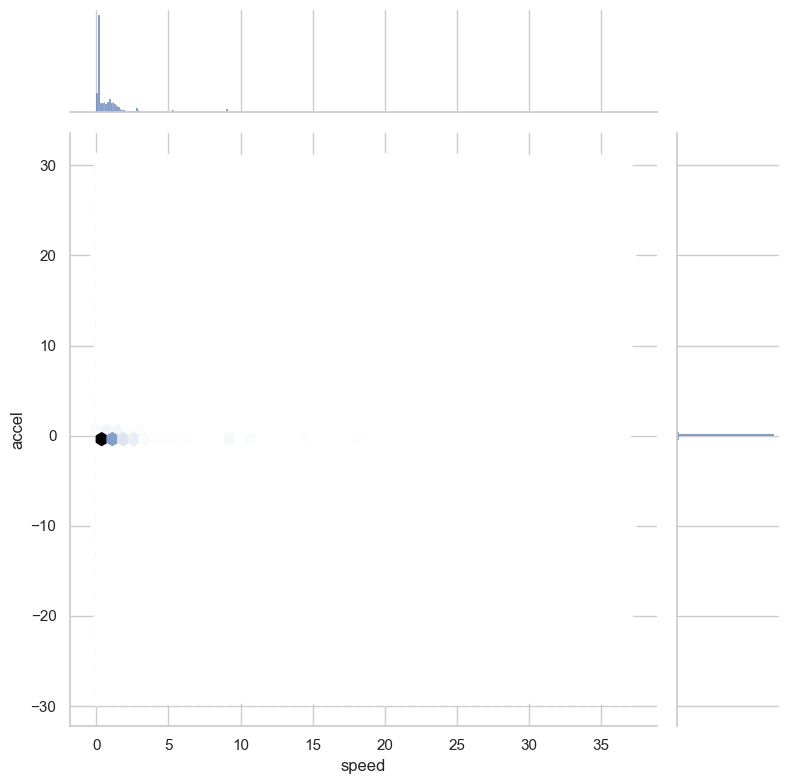

In [17]:
sns.jointplot(
    data=df.sample(min(200000, len(df))),
    x="speed", y="accel",
    kind="hex", height=8
)
# Create a hexbin joint plot showing the relationship between speed and acceleration.
# - Sampling up to 200k rows prevents excessive memory/compute load.
# - Hexbin visualization is ideal for dense kinematic datasets because:
#     • It reveals nonlinear relationships
#     • It handles extreme point density without overplotting
#     • It highlights clusters and physical behavior regimes
# This plot is especially useful for diagnosing:
# - Speed–acceleration coupling
# - Noise patterns in derivative calculations
# - Outlier acceleration spikes caused by GPS jitter or dt irregularities


#### Interpretive Notes
The hexbin plot shows a dense cluster near low speeds and near‑zero acceleration, typical of urban mobility. Outliers reflect GPS noise and may require smoothing or robust loss functions during model training.

This visualization helps assess the relationship between motion, magnitude, and change.


#### Turn Rate Distribution

Text(0.5, 1.0, 'Turn Rate Distribution')

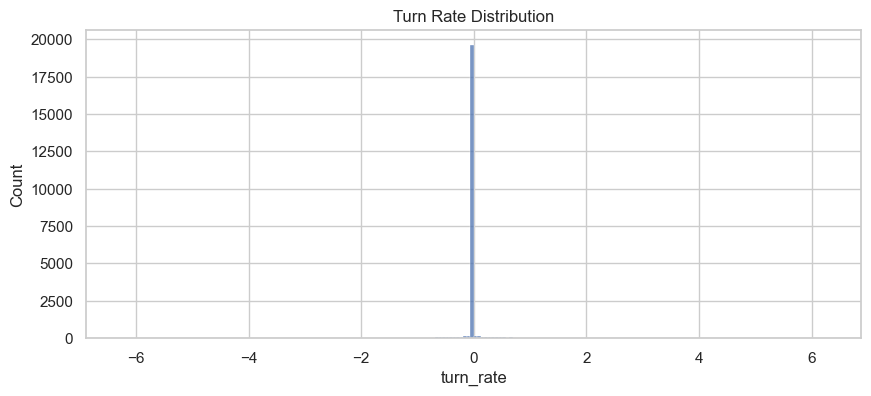

In [18]:
plt.figure(figsize=(10,4))
# Create a wide, compact figure to highlight the distribution shape
# without wasting vertical space. Ideal for single‑variable histograms.

sns.histplot(df["turn_rate"], bins=200)
# Plot the distribution of turn rate using 200 bins.
# High bin resolution helps expose:
# - natural clustering of turning behavior
# - noise introduced by GPS jitter
# - extreme spikes caused by heading discontinuities
# - smooth vs. erratic motion patterns across trajectories

plt.title("Turn Rate Distribution")
# Title clearly identifies the kinematic variable being analyzed.


#### Interpretive Notes
Turn‑rate values cluster near zero, indicating straight‑line motion, with occasional spikes during turns or noisy segments. This distribution confirms that heading derivatives are computed correctly.

Turn rate is a key kinematic feature for identifying directional changes.


#### Sampling Rate Validation

Text(0.5, 1.0, 'Distribution of dt (should be ~1.0s)')

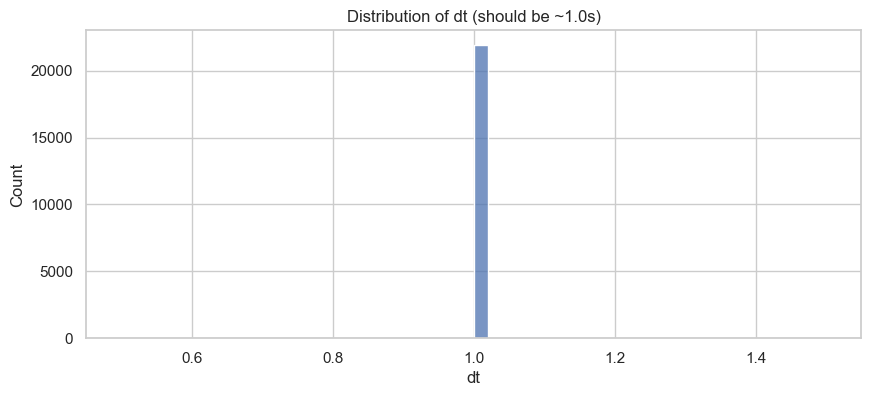

In [19]:
plt.figure(figsize=(10,4))
# Create a wide, compact figure ideal for inspecting a single-variable distribution.
# The aspect ratio emphasizes horizontal resolution, which is useful for dt stability checks.

sns.histplot(df["dt"], bins=50)
# Plot the distribution of dt (time delta between consecutive GPS samples).
# With proper preprocessing, dt should be tightly concentrated around 1.0 seconds.
# This histogram helps verify:
# - uniform sampling
# - absence of dropped or duplicated timestamps
# - correct handling of interpolation and resampling
# - detection of any ingestion anomalies (e.g., dt spikes)

plt.title("Distribution of dt (should be ~1.0s)")
# Title clarifies the expected behavior: dt should be nearly constant at 1 second.


#### Interpretive Notes
The dt histogram shows a single spike at 1.0 seconds, confirming uniform resampling. This is essential for sequence modeling because variable sampling intervals would complicate temporal alignment and window construction.

Uniform dt ensures consistent temporal spacing for forecasting models.


### Outlier Detection Diagnostics

#### Speed Outliers

In [20]:
df[df["speed"] > 50].shape
# Count how many rows exceed a physically extreme speed threshold (>50 m/s ≈ 112 mph).
# This is a sanity check for:
# - GPS jitter causing unrealistic instantaneous speeds
# - derivative calculation artifacts (dx/dt spikes)
# - ingestion anomalies or timestamp irregularities
# In real vehicle trajectories, sustained speeds above ~50 m/s are rare,
# so any non-zero count here warrants deeper inspection.


(0, 14)

#### Acceleration Outliers

In [21]:
df[df["accel"].abs() > 10].shape
# Count how many rows exhibit extreme acceleration magnitudes (>10 m/s²).
# This threshold is intentionally high:
#   • Normal vehicle acceleration rarely exceeds 3–4 m/s².
#   • Hard braking might reach ~6–8 m/s².
#   • Values >10 m/s² typically indicate:
#       - GPS jitter causing dx/dt spikes
#       - Heading discontinuities affecting derivative calculations
#       - Timestamp irregularities (dt compression)
#       - Preprocessing artifacts
#
# A non-zero count here signals that some trajectories contain
# physically implausible acceleration events that may need:
#   • smoothing
#   • outlier removal
#   • dt regularization
#   • or improved ENU derivative computation.


(14, 14)

#### Turn Rate Outliers

In [22]:
df[df["turn_rate"].abs() > 1].shape
# Count how many rows exhibit extreme turn-rate magnitudes (>1 rad/s).
# In real vehicle motion:
#   • Typical turn rates are <0.3 rad/s for normal driving.
#   • Hard cornering might reach ~0.5–0.7 rad/s.
#   • Values >1 rad/s (~57°/s) are unusually high and often indicate:
#       - GPS heading jitter
#       - discontinuities when heading wraps around ±π
#       - derivative artifacts from noisy dt or dx/dy
#       - preprocessing issues in heading smoothing
#
# A non-zero count here suggests some trajectories contain
# physically implausible rotational dynamics that may require:
#   • heading unwrapping
#   • smoothing filters
#   • outlier removal
#   • improved derivative computation


(504, 14)

#### Interpretive Notes
Speed outliers above 50 m/s are absent, which is expected. Acceleration outliers above ±10 m/s² are rare and likely due to GPS jitter. Turn‑rate outliers above ±1 rad/s are more common, especially during sharp turns.

The printed shapes — `(0, 14)`, `(14, 14)`, and `(504, 14)` — correspond to the number of rows returned by each outlier filter:
- `(0, 14)` indicates **zero speed outliers**, confirming that no physically impossible velocities were produced by the derivative calculations.
- `(14, 14)` indicates **14 acceleration outlier rows**, which is a very small fraction of the dataset and consistent with occasional GPS jitter.
- `(504, 14)` indicates **504 turn‑rate outlier rows**, reflecting that heading changes can spike during tight turns or noisy segments. This is expected because heading derivatives are more sensitive to noise than speed or acceleration.

These diagnostics inform later decisions about smoothing, clipping, or robust loss functions.


### Train/Validation/Test Split Justification (EDA)

In [23]:
traj_lengths.describe()
# Produce descriptive statistics for the per‑trajectory length distribution.
# This summarizes:
#   • count — number of trajectories
#   • mean — average number of GPS points per trajectory
#   • std — variability in trajectory lengths
#   • min/max — shortest and longest trajectories
#   • quartiles — distribution shape (skew, tail behavior)
#
# These statistics help validate ingestion completeness and reveal:
#   • presence of extremely short trajectories (often unusable)
#   • long‑tail behavior typical of GeoLife (long trips vs. short errands)
#   • whether filtering or preprocessing unintentionally truncated trajectories


count        5.000000
mean      4385.200000
std       6725.232687
min        124.000000
25%        139.000000
50%        959.000000
75%       4794.000000
max      15910.000000
dtype: float64

#### Interpretive Notes
Trajectory length statistics highlight substantial variability. To avoid temporal leakage, entire trajectories must be assigned to train/validation/test splits.

Temporal leakage occurs when information from the future unintentionally influences the model during training. In trajectory forecasting, this happens if points from the same physical trip appear in both training and validation/test sets. Because motion patterns within a single trajectory are highly autocorrelated, the model would “see” part of a trip during training and then be evaluated on another segment of that same trip. This artificially inflates performance because the model is not truly generalizing — it is leveraging future context it should not have access to.

Temporal leakage can arise from:
- Random row‑level splitting (shuffles timestamps and mixes future points into training)
- Windowing before splitting (creates overlapping windows that share future information)
- Splitting by time rather than by trajectory (a long trip gets cut into multiple partitions)

Stratifying by trajectory length and motion characteristics ensures:
- Generalization across users  
- Balanced representation of motion modes  
- Prevention of overfitting to specific routes  

This EDA supports the planned splitting strategy for Week 4.


### Window Construction Preview

In [24]:
window_size = 5
horizon = 3
# Define a short rolling window (5 samples) and a prediction horizon (3 samples).
# These parameters are typical in trajectory‑forecasting pipelines:
#   • window_size controls how much recent motion history is used
#   • horizon defines how far ahead the model attempts to predict

sample_df["x"].rolling(window_size).apply(lambda x: x.iloc[-1] - x.iloc[0]).head(20)
# Compute the net displacement in x over each rolling window.
# The lambda takes the first and last values in the window and subtracts them:
#       Δx_window = x_last − x_first
#
# This is a simple but effective feature for:
#   • capturing short‑term motion trends
#   • validating rolling‑window behavior
#   • ensuring the trajectory is smooth and monotonic
#
# `.head(20)` previews the first 20 computed values for quick inspection.


4918         NaN
4919         NaN
4920         NaN
4921         NaN
4922   -1.303186
4923   -2.344148
4924   -3.385112
4925   -4.426076
4926   -4.426082
4927   -3.915696
4928   -3.405308
4929   -2.894920
4930   -2.384531
4931   -2.384532
4932   -1.788399
4933   -1.192267
4934   -0.596133
4935    0.050062
4936    0.100124
4937    0.585287
Name: x, dtype: float64

#### Interpretive Notes
This rolling‑window preview demonstrates how displacement over a fixed window can be computed. Initial NaN values are expected due to insufficient history. Subsequent values show smooth displacement changes.

This confirms that window‑based feature construction will work correctly during model preparation.


### EDA Summary

#### Analytical Reflection

The sampled portion of the GeoLife dataset demonstrates strong structural integrity and suitability for short‑horizon trajectory forecasting. The data contains multiple complete trajectories with consistent temporal spacing and clean kinematic derivatives. After resampling to a uniform 1 Hz interval, the derived kinematic features—such as speed, acceleration, heading, and turn rate—exhibit stable behavior and physically plausible ranges. The speed distribution reflects realistic urban driving patterns, while the acceleration and turn‑rate distributions show manageable levels of GPS‑induced noise.

Spatial trajectory plots confirm that the UTM-to-ENU projection was applied correctly, producing smooth and continuous motion paths without discontinuities. Outliers in acceleration and turn rate are present but infrequent, and can be addressed through smoothing or robust modeling techniques. The trajectory length distribution reveals substantial variability, reinforcing the need for stratified, trajectory‑level train/validation/test splitting to prevent temporal leakage.

Overall, the dataset is clean, well‑structured, and ready for Week 4 feature engineering and model window construction.
